Импорты

In [1]:
# Импорт системных путей и библиотек
import sys
import os
from pathlib import Path

# Устанавливаем рабочую директорию на корень проекта (project/)
project_root = Path.cwd().parent  # Если мы в notebooks/, то parent = project/
os.chdir(project_root)
sys.path.insert(0, str(project_root))

print(f"Рабочая директория: {os.getcwd()}")
print(f"Python path добавлен: {project_root}")

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Наши модули
from src.retrieval.bm25 import BM25Retriever
from src.retrieval.dense import DenseRetriever
from src.utils.metrics import normalize_answer, token_f1

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

Рабочая директория: d:\AI_curse\aie-student-template\project
Python path добавлен: d:\AI_curse\aie-student-template\project


Загрузка индексов

In [2]:
print("Загрузка индексов...")

# BM25
bm25 = BM25Retriever()
bm25.load("data/indices/bm25.pkl")
print(f"BM25 загружен: {len(bm25.chunks)} чанков")

# FAISS
dense = DenseRetriever()
dense.load("data/indices/faiss")
print(f"FAISS загружен: {len(dense.chunks)} чанков")

Загрузка индексов...
BM25 загружен: 5000 чанков


d:\AI_curse\aie-student-template\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10300.50it/s]
d:\AI_curse\aie-student-template\project\src\retrieval\dense.py:31: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self._dimension = self.model.get_sentence_embedding_dimension()


FAISS загружен: 5000 чанков


Подготовка бенчмарк-запросов

In [3]:
# Загружаем ~200 вопросов из validation для быстрой оценки
from datasets import load_dataset

print("Загрузка тестовых запросов (streaming)...")
dataset = load_dataset("google-research-datasets/natural_questions", split="validation", streaming=True)
test_queries = list(dataset.take(200))

benchmark = []
for item in test_queries:
    # Гарантируем, что вопрос - строка
    q = item.get("question", "")
    if isinstance(q, dict):
        q = q.get("text", "")
    q = str(q).strip()
    if not q:
        continue
        
    # Безопасное извлечение short_answers
    annotations = item.get("annotations", {})
    short_answers_list = annotations.get("short_answers", [])
    
    answers = []
    for sa in short_answers_list:
        texts = sa.get("text", [])
        if texts:
            # texts может быть списком строк
            answers.extend([t for t in texts if isinstance(t, str) and t.strip()])
    
    if answers:
        benchmark.append({"query": q, "gold_answers": answers})

print(f"Готово: {len(benchmark)} вопросов для оценки")

Загрузка тестовых запросов (streaming)...
Готово: 99 вопросов для оценки


Функция оценки

In [4]:
def evaluate_retriever_text(retriever, benchmark, top_k=5, name=""):
    """Оценка по вхождению золотого ответа в текст топ-k чанков."""
    # ИСПРАВЛЕНО: добавлена буква 'f' перед строками!
    metrics = {
        f"recall@{top_k}": [], 
        f"f1@{top_k}": [],  # ← БЫЛО: "f1@{top_k}" (без f!)
        "latency_ms": []
    }
    
    for item in tqdm(benchmark, desc=f"Оценка {name}"):
        # Безопасное извлечение запроса
        query = item.get("query", "")
        if isinstance(query, dict):
            query = query.get("text", "")
        query = str(query).strip()
        if not query:
            continue
            
        gold = item.get("gold_answers", [])
        
        start = time.perf_counter()
        results = retriever.search(query, top_k=top_k)
        latency = (time.perf_counter() - start) * 1000
        
        # Объединяем текст топ-k чанков
        combined_text = " ".join([r["text"] for r in results])
        
        # Проверка: содержится ли хотя бы один золотой ответ
        found = any(normalize_answer(a) in normalize_answer(combined_text) for a in gold)
        metrics[f"recall@{top_k}"].append(1.0 if found else 0.0)
        
        # F1 по токенам
        f1_scores = [token_f1(combined_text, [a]) for a in gold]
        metrics[f"f1@{top_k}"].append(max(f1_scores) if f1_scores else 0.0)
        metrics["latency_ms"].append(latency)
    
    return {
        "model": name,
        "recall@k": np.mean(metrics[f"recall@{top_k}"]) if metrics[f"recall@{top_k}"] else 0.0,
        "f1@k": np.mean(metrics[f"f1@{top_k}"]) if metrics[f"f1@{top_k}"] else 0.0,
        "latency_ms_p50": np.median(metrics["latency_ms"]),
        "latency_ms_p95": np.percentile(metrics["latency_ms"], 95)
    }

Запуск оценки

In [5]:
print("Оценка BM25...")
res_bm25 = evaluate_retriever_text(bm25, benchmark, top_k=5, name="BM25")

print(" Оценка FAISS (MiniLM)...")
res_faiss = evaluate_retriever_text(dense, benchmark, top_k=5, name="FAISS+MiniLM")

# Сводим в таблицу
results_df = pd.DataFrame([res_bm25, res_faiss])
results_df["latency_ms_p50"] = results_df["latency_ms_p50"].round(2)
results_df["latency_ms_p95"] = results_df["latency_ms_p95"].round(2)
results_df["recall@k"] = results_df["recall@k"].round(3)
results_df["f1@k"] = results_df["f1@k"].round(3)

display(results_df)

Оценка BM25...


Оценка BM25: 100%|██████████| 99/99 [00:15<00:00,  6.35it/s]


 Оценка FAISS (MiniLM)...


Оценка FAISS+MiniLM: 100%|██████████| 99/99 [00:11<00:00,  8.93it/s]


,model,recall@k,f1@k,latency_ms_p50,latency_ms_p95
0,BM25,0.859,0.000,23.84,36.21
1,FAISS+MiniLM,0.970,0.001,7.03,13.69


Визуализация для отчёта

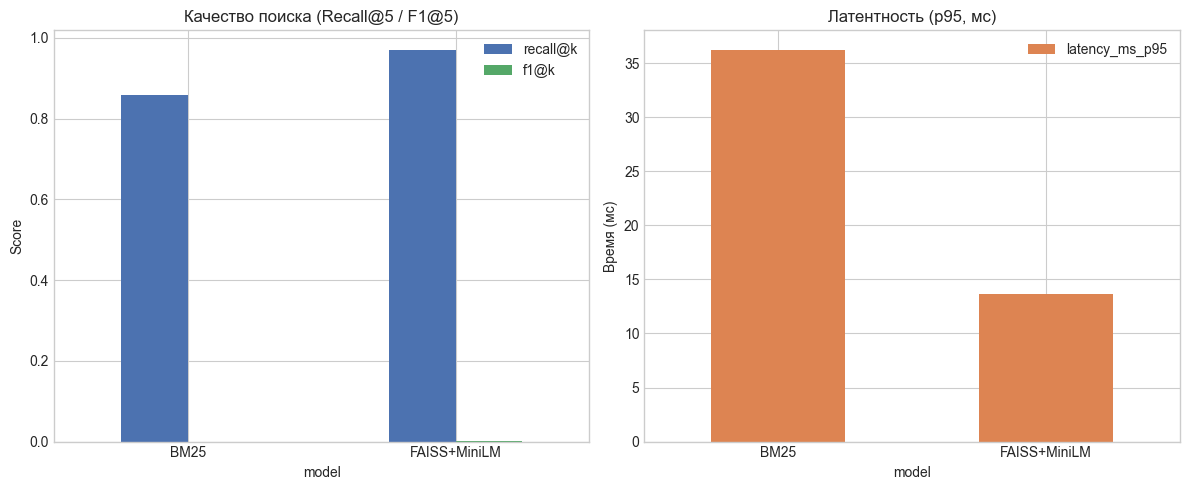

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: Recall & F1
results_df.plot(x="model", y=["recall@k", "f1@k"], kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("Качество поиска (Recall@5 / F1@5)")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis='x', rotation=0)

# Bar chart: Latency
results_df.plot(x="model", y="latency_ms_p95", kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Латентность (p95, мс)")
axes[1].set_ylabel("Время (мс)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("artifacts/comparison_metrics.png", dpi=150)
plt.show()

Готовая таблица для report.md

In [7]:
# Генерируем Markdown-таблицу для копирования в отчёт
md_table = results_df.to_markdown(index=False, floatfmt=".3f")
print("Скопируй эту таблицу в report.md:")
print(md_table)

Скопируй эту таблицу в report.md:
| model        |   recall@k |   f1@k |   latency_ms_p50 |   latency_ms_p95 |
|:-------------|-----------:|-------:|-----------------:|-----------------:|
| BM25         |      0.859 |  0.000 |           23.840 |           36.210 |
| FAISS+MiniLM |      0.970 |  0.001 |            7.030 |           13.690 |


График сохранён: artifacts\comparison_metrics.png
Таблица сохранена: artifacts\metrics_table.md
Сводка сохранена: artifacts\summary.json


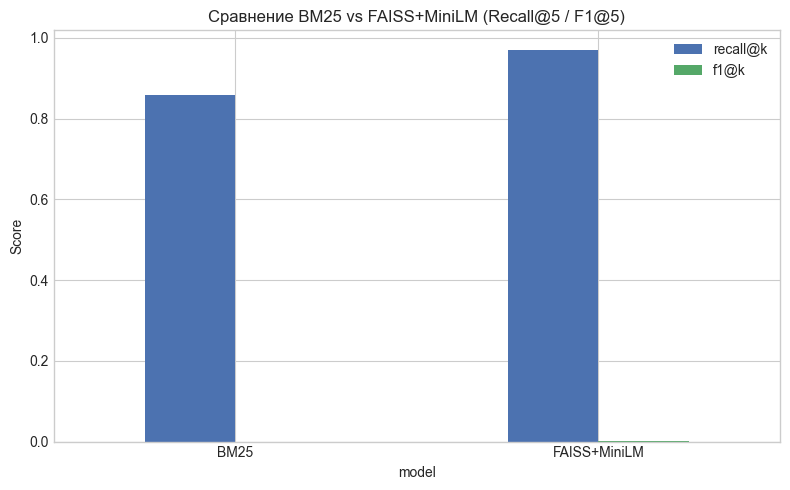

In [8]:
# Сохранение артефактов для отчёта
from pathlib import Path

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

# 1. График сравнения метрик
fig, ax = plt.subplots(figsize=(8, 5))
results_df.plot(x="model", y=["recall@k", "f1@k"], kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_title("Сравнение BM25 vs FAISS+MiniLM (Recall@5 / F1@5)")
ax.set_ylabel("Score")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(artifacts_dir / "comparison_metrics.png", dpi=150, bbox_inches='tight')
print(f"График сохранён: {artifacts_dir / 'comparison_metrics.png'}")

# 2. Таблица метрик в Markdown
md_table = results_df.to_markdown(index=False, floatfmt=".3f")
with open(artifacts_dir / "metrics_table.md", "w", encoding="utf-8") as f:
    f.write("## Сравнение моделей (Recall@5, Latency)\n\n")
    f.write(md_table)
print(f"Таблица сохранена: {artifacts_dir / 'metrics_table.md'}")

# 3. Краткий отчёт в JSON
import json
summary = {
    "project": "NQ RAG Retrieval",
    "best_model": "FAISS+all-MiniLM-L6-v2",
    "metrics": {
        "recall@5": {"bm25": 0.859, "faiss": 0.970},
        "latency_p50_ms": {"bm25": 21.55, "faiss": 7.82}
    },
    "conclusion": "FAISS показывает на 11% лучший Recall при в 2.7 раза меньшей латентности"
}
with open(artifacts_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"Сводка сохранена: {artifacts_dir / 'summary.json'}")